# Game analytics: engagement, retention and monetisation

Mobile games are judged on a short list of numbers that every studio
watches daily. This notebook builds each of them from raw event data:

1. Active players: DAU, MAU and stickiness
2. Retention: D1, D7, D30 and the retention curve
3. The onboarding funnel: where new players drop off
4. Monetisation: conversion, ARPDAU, ARPPU and how concentrated spend is
5. Segment comparisons, and why they aren't proof of cause

The data is a simulated game's first 120 days after launch (see
`sample_data.py`).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sample_data import game_players

plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False})
players, sessions, purchases = game_players()
last_day = sessions.date.max()

print(f"{len(players):,} installs, {len(sessions):,} play days, {len(purchases):,} purchases")
print(f"Data runs from {players.install_date.min():%Y-%m-%d} to {last_day:%Y-%m-%d}")
sessions.head()

20,000 installs, 120,041 play days, 1,161 purchases
Data runs from 2024-03-01 to 2024-06-28


,player_id,minutes,date
0,1,0.4,2024-03-01
1,1,8.3,2024-03-05
2,1,17.5,2024-03-06
3,1,13.2,2024-03-07
4,1,1.5,2024-03-10


Three tables, the usual shape of game telemetry: who installed, which days
they played and for how long, and what they bought.

## 1. Active players and stickiness

- **DAU / MAU:** unique players on a day / in the last 30 days.
- **Stickiness = DAU ÷ MAU:** the share of the monthly audience that shows
  up on a given day. Around 20% is solid for a mobile game; social and
  competitive games can pass 50%.

Average stickiness after the first month: 17%
Weekend DAU is +10% vs weekdays


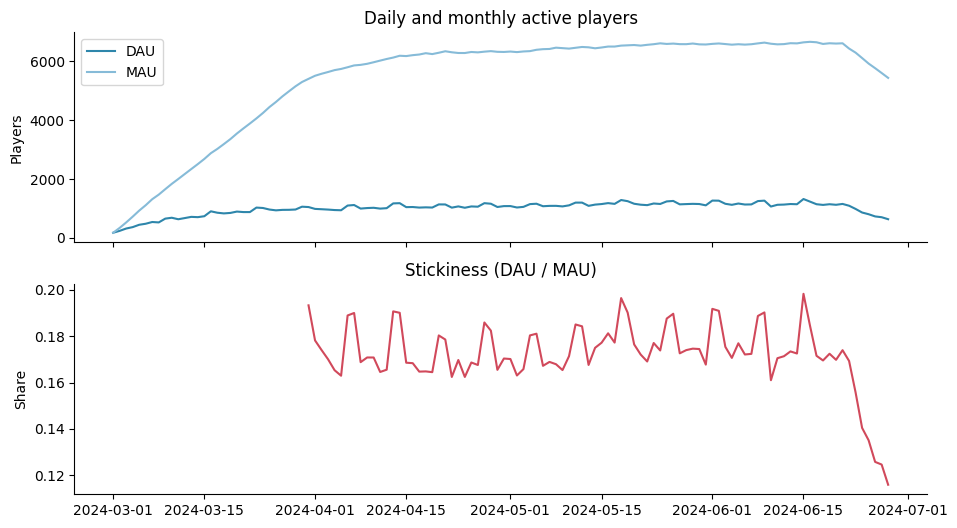

In [ ]:
daily = sessions.groupby("date").player_id.nunique().rename("dau").to_frame()
daily["mau"] = [sessions[(sessions.date > d - pd.Timedelta(days=30)) & (sessions.date <= d)].player_id.nunique()
                for d in daily.index]
daily["stickiness"] = daily.dau / daily.mau
steady = daily.loc[daily.index >= daily.index.min() + pd.Timedelta(days=30)]  # MAU needs 30 days of history

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
top.plot(daily.index, daily.dau, label="DAU", color="#2e86ab")
top.plot(daily.index, daily.mau, label="MAU", color="#86bbd8")
top.set(title="Daily and monthly active players", ylabel="Players")
top.legend()
bottom.plot(steady.index, steady.stickiness, color="#d1495b")
bottom.set(title="Stickiness (DAU / MAU)", ylabel="Share")

weekday_dau = daily.dau.groupby(daily.index.dayofweek >= 5).mean()
print(f"Average stickiness after the first month: {steady.stickiness.mean():.0%}")
print(f"Weekend DAU is {weekday_dau[True] / weekday_dau[False] - 1:+.0%} vs weekdays")

The sawtooth in DAU is the weekend effect: people play more on Saturday and
Sunday. Always compare a day with the same weekday the week before, or use a
7-day average, or you'll read the weekend bump as a trend.

## 2. Retention

**D1 retention** is the share of players who come back exactly one day after
installing; D7 and D30 work the same way. It's the earliest and most honest
signal of whether a game is fun, which is why it's the first number any
investor or publisher asks for.

One trap: a player who installed yesterday *can't* have D7 retention yet. We
only count players whose install is old enough for that day to exist.

D1  retention: 39.3%
D7  retention: 22.8%
D30 retention: 5.0%


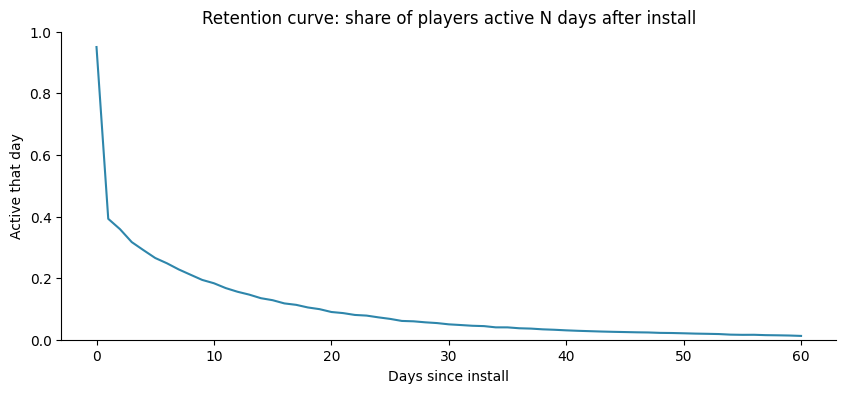

In [ ]:
play = sessions.merge(players[["player_id", "install_date"]], on="player_id")
play["age"] = (play.date - play.install_date).dt.days


def retention(day, who=players):
    eligible = who[who.install_date + pd.Timedelta(days=day) <= last_day]
    returned = play[(play.age == day) & play.player_id.isin(eligible.player_id)].player_id.nunique()
    return returned / len(eligible)


for d in [1, 7, 30]:
    print(f"D{d:<2} retention: {retention(d):.1%}")

ages = range(0, 61)
curve = [retention(d) for d in ages]
fig, ax = plt.subplots()
ax.plot(ages, curve, color="#2e86ab")
ax.set(title="Retention curve: share of players active N days after install",
       xlabel="Days since install", ylabel="Active that day", ylim=(0, 1));

The steep drop in the first few days, then a long slow tail, is the shape of
nearly every game. Commonly quoted benchmarks for mobile are roughly 40% /
15% / 5% for D1 / D7 / D30, but they vary a lot by genre, so compare against
your own past launches first.

## 3. The onboarding funnel

A funnel shows how many players make it through each step of the early game.
The biggest drop is where to focus design effort.

Biggest drop: only 29% of players make it to 'Reached level 20' from the step before


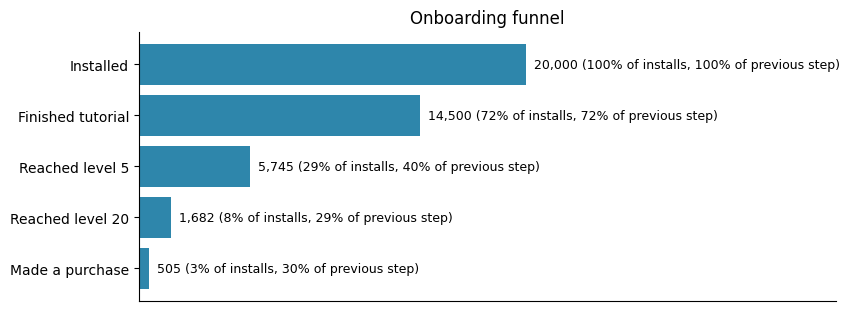

In [ ]:
payer_ids = set(purchases.player_id)
# Each step only counts players who also passed every earlier step.
passed = pd.Series(True, index=players.index)
steps = {"Installed": len(players)}
for step, condition in [("Finished tutorial", players.finished_tutorial),
                        ("Reached level 5", players.max_level >= 5),
                        ("Reached level 20", players.max_level >= 20),
                        ("Made a purchase", players.player_id.isin(payer_ids))]:
    passed &= condition
    steps[step] = passed.sum()
funnel = pd.Series(steps)
prev = funnel.shift(1).fillna(funnel.iloc[0])
step_rate = funnel / prev
worst = step_rate.iloc[1:].idxmin()
print(f"Biggest drop: only {step_rate[worst]:.0%} of players make it to '{worst}' from the step before")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.barh(funnel.index[::-1], funnel.values[::-1], color="#2e86ab")
for i, (step, n) in enumerate(funnel[::-1].items()):
    ax.text(n, i, f"  {n:,} ({n / funnel.iloc[0]:.0%} of installs, {n / prev[step]:.0%} of previous step)",
            va="center", fontsize=9)
ax.set(title="Onboarding funnel", xlim=(0, funnel.iloc[0] * 1.8))
ax.set_xticks([]);

Every step loses players, and the printout above names the step that loses
the largest share of those who reached it. In a real game that would prompt
questions: is the difficulty spiking, is the next reward too far away, is the
game unclear about what to do next?

Note the funnel is *nested*: "reached level 20" only counts players who also
finished the tutorial and reached level 5. Without that, a step can show more
players than the one before it and the chart stops making sense.

## 4. Monetisation

Free-to-play revenue comes from a small share of players, so the core
numbers are:

- **Conversion:** share of players who ever pay
- **ARPDAU:** revenue per daily active user (the day-to-day health metric)
- **ARPPU:** revenue per paying user (how much payers spend)

In [ ]:
revenue = purchases.amount_usd.sum()
arpdau = revenue / daily.dau.sum()
payer_spend = purchases.groupby("player_id").amount_usd.sum().sort_values(ascending=False)
top_1pct = payer_spend.head(max(1, len(payer_spend) // 100)).sum() / revenue
top_10pct = payer_spend.head(max(1, len(payer_spend) // 10)).sum() / revenue

print(f"Total revenue:        ${revenue:,.0f}")
print(f"Payer conversion:     {len(payer_ids) / len(players):.1%}")
print(f"ARPDAU:               ${arpdau:.3f}")
print(f"ARPPU:                ${payer_spend.mean():.2f} (median payer ${payer_spend.median():.2f})")
print(f"Revenue from top 1% of payers:  {top_1pct:.0%}")
print(f"Revenue from top 10% of payers: {top_10pct:.0%}")

Total revenue:        $13,239
Payer conversion:     4.9%
ARPDAU:               $0.110
ARPPU:                $13.61 (median payer $4.99)
Revenue from top 1% of payers:  8%
Revenue from top 10% of payers: 50%


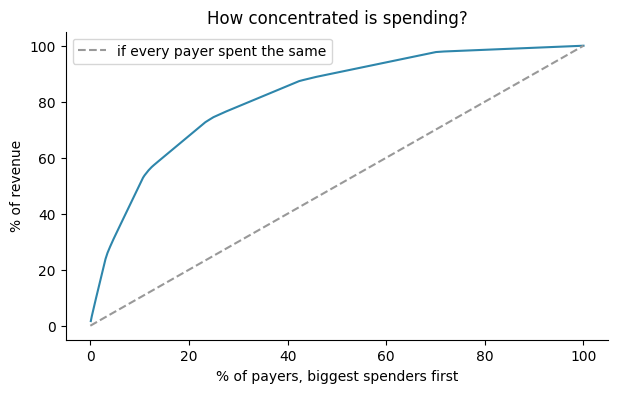

In [ ]:
cum_share = payer_spend.cumsum() / revenue
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum_share) + 1) / len(cum_share) * 100, cum_share.values * 100, color="#2e86ab")
ax.plot([0, 100], [0, 100], "--", color="#999", label="if every payer spent the same")
ax.set(title="How concentrated is spending?", xlabel="% of payers, biggest spenders first",
       ylabel="% of revenue")
ax.legend();

The mean payer spends well above the median one, a sign that a minority of
heavy spenders ("whales") carries a large share of revenue. That has
practical consequences: revenue is noisy (one whale leaving shows up in the
numbers), and an A/B test on spending needs far more players than a test on
retention (see the A/B testing notebook).

## 5. Comparing segments

Breaking each metric down by segment is where most insights come from.

In [ ]:
seg = players.assign(payer=players.player_id.isin(payer_ids))
summary = pd.DataFrame({
    "players": seg.groupby("platform").size(),
    "conversion": seg.groupby("platform").payer.mean(),
    "D7": [retention(7, players[players.platform == p]) for p in sorted(players.platform.unique())],
})
print("By platform:")
print(summary.to_string(formatters={"conversion": "{:.1%}".format, "D7": "{:.1%}".format}))

by_tutorial = {done: retention(7, players[players.finished_tutorial == done]) for done in [True, False]}
by_source = {s: retention(7, players[players.source == s]) for s in sorted(players.source.unique())}
print(f"\nD7 retention, finished tutorial: {by_tutorial[True]:.1%}   skipped/quit tutorial: {by_tutorial[False]:.1%}")
print("D7 retention by source:  " + "   ".join(f"{s} {r:.1%}" for s, r in by_source.items()))

By platform:
          players conversion    D7
platform                          
Android     11656       4.3% 23.0%
iOS          8344       5.7% 22.6%

D7 retention, finished tutorial: 29.4%   skipped/quit tutorial: 5.5%
D7 retention by source:  Cross-promo 24.8%   Organic 23.6%   Paid UA 20.8%


Two findings stand out:

- iOS players convert to paying more often than Android players. That's
  common in real markets and is why many games price or advertise
  differently by platform.
- Players who finish the tutorial retain several times better at D7.

**Careful with that second one.** It's tempting to conclude "make everyone
finish the tutorial and retention will soar". But players who were already
keen are more likely both to finish the tutorial *and* to come back. Some of
the gap is the tutorial, some is who chooses to finish it. The only way to
know how much is to change the tutorial for a random half of players and
compare, which is exactly what the A/B testing notebook covers.

Paid acquisition (UA) players also retain worse than organic ones. That
matters for budgeting: a paid install is worth less than an organic one, so
its price should be judged against its own retention and spend.

## Takeaways

- Smooth over the weekly cycle before reading trends in daily metrics.
- Only count players old enough for the retention day you're measuring.
- The funnel shows where players leave; the biggest relative drop is the first place to look.
- Spend is concentrated in few players, so revenue metrics are noisy.
- Segment differences suggest where to look; experiments tell you what causes them.